# JAX based BCDI phase retrieval

In [8]:
import os

# must be set BEFORE `import jax` — JAX reads this once at backend init
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.42"   # ~20 GiB on a 48 GiB A40

import jax
print(jax.devices())

import numpy as np
# from jax_model_allfunctions import *
import sys
import time 
import pynx
import cdiutils
import convexad_jax
from convexad_jax.optimize import reconstruct

sys.path.append('/data/id01/inhouse/bellec/software/sharedipynb/gitlab/bcdi_eb/')
from Global_utilities import *
from Object_utilities import *
# from Plot_utilities import *


[CudaDevice(id=0)]


# Load data

In [9]:
Iobs = np.load("../../ad_github/notebooks/data_prova.npz")["I"].astype(np.float32)
key = jax.random.PRNGKey(0)

# plot_3D_projections(Iobs)

# Solve PR

In [10]:
t0 = time.time()
result = reconstruct(
    key,
    Iobs,
    n_restarts = 32,
    N=128,
    size_factor=4.0,
    eps=0.9,
    alpha=0.0,
    beta=0.0,
    metric="mae",
    phase_type="displacement",
    phase_kwargs={'hkl': [2,2,2]},
    support_type="single",
    # support_kwargs={'M_parts': 3, 'N_per_part': 32},
    optimizer="adam",
    max_steps=1000,
    tol=1e-6,
    memory_size=10,
    learning_rate=0.05,
    grid_shape=None,
)
print(f"done in {time.time() - t0:.1f}s")

done in 110.2s


In [11]:
print("best loss:", float(result.best_loss))
print("steps per restart:", result.all_steps)


best loss: 0.11468970030546188
steps per restart: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000
 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000
 1000 1000 1000 1000]


In [41]:
support, amplitude, phase = result.evaluate(Iobs)

modulus = amplitude*support
obj = modulus*phase[0] + 1.0j*modulus*phase[1]


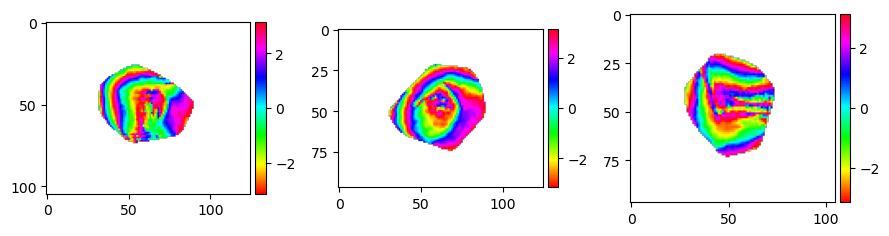

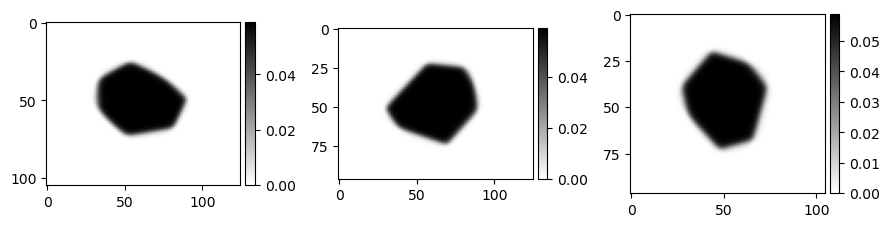

In [42]:
plot_2D_slices_middle_only_phase(obj, unwrap = False)
plot_2D_slices_middle_only_module(obj)

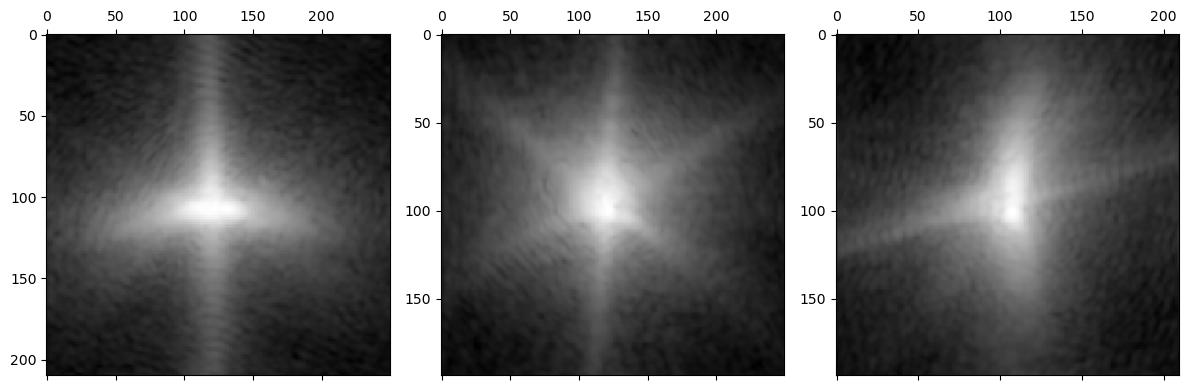

In [43]:
def _center_pad(obj, target_shape):
    pads = []
    for src, dst in zip(obj.shape, target_shape):
        delta = dst - src
        p0 = delta // 2
        p1 = delta - p0
        pads.append((p0, p1))
    return jnp.pad(obj, pads)
obj_p = _center_pad(obj, Iobs.shape)

Icalc = np.abs(ifftshift(fftn(fftshift(obj_p))))
plot_3D_projections(Icalc)

In [ ]:
# np.savez('core_12_JAX_1.npz', obj = obj_p, data = Iobs)